In [ ]:
!pip install google-genai pillow
#

In [2]:
from google import genai
from PIL import Image

In [ ]:
API_KEY = "api_key"

client = genai.Client(api_key=API_KEY)

In [7]:
deadline_prompt = """
You are an AI Academic Deadline Tracker.

Analyze the uploaded image carefully. The image may contain a syllabus, timetable, assignment sheet, project schedule, or other academic documents.

Your task is to extract all important academic deadlines, exam dates, and milestones clearly visible in the image.

Please present the extracted information in a structured Markdown table, sorted chronologically (earliest to latest), with the following columns:
- **Date & Time:** (e.g., Oct 15, 11:59 PM)
- **Task / Event:** (The name of the assignment, reading, or test)
- **Subject / Course:** (The relevant class, if visible)
- **Type:** (Assignment, Exam, Project, Quiz, Reading, or Other)
- **Additional Notes:** (Weightage, submission method, location, or specific instructions)

Rules for extraction:
1. If any specific piece of information for a column is missing, write "Not specified".
2. Do not invent, guess, or calculate dates unless a clear reference point is provided in the document (e.g., "Week 1 starts Sept 1").
3. Only include dates that are explicitly associated with an academic event or deadline. Do not treat unrelated dates such as document creation dates, publication dates, or page headers as deadlines.
4. If the image does not contain any identifiable academic deadlines, clearly state: "No academic deadlines were found in the provided image."
"""

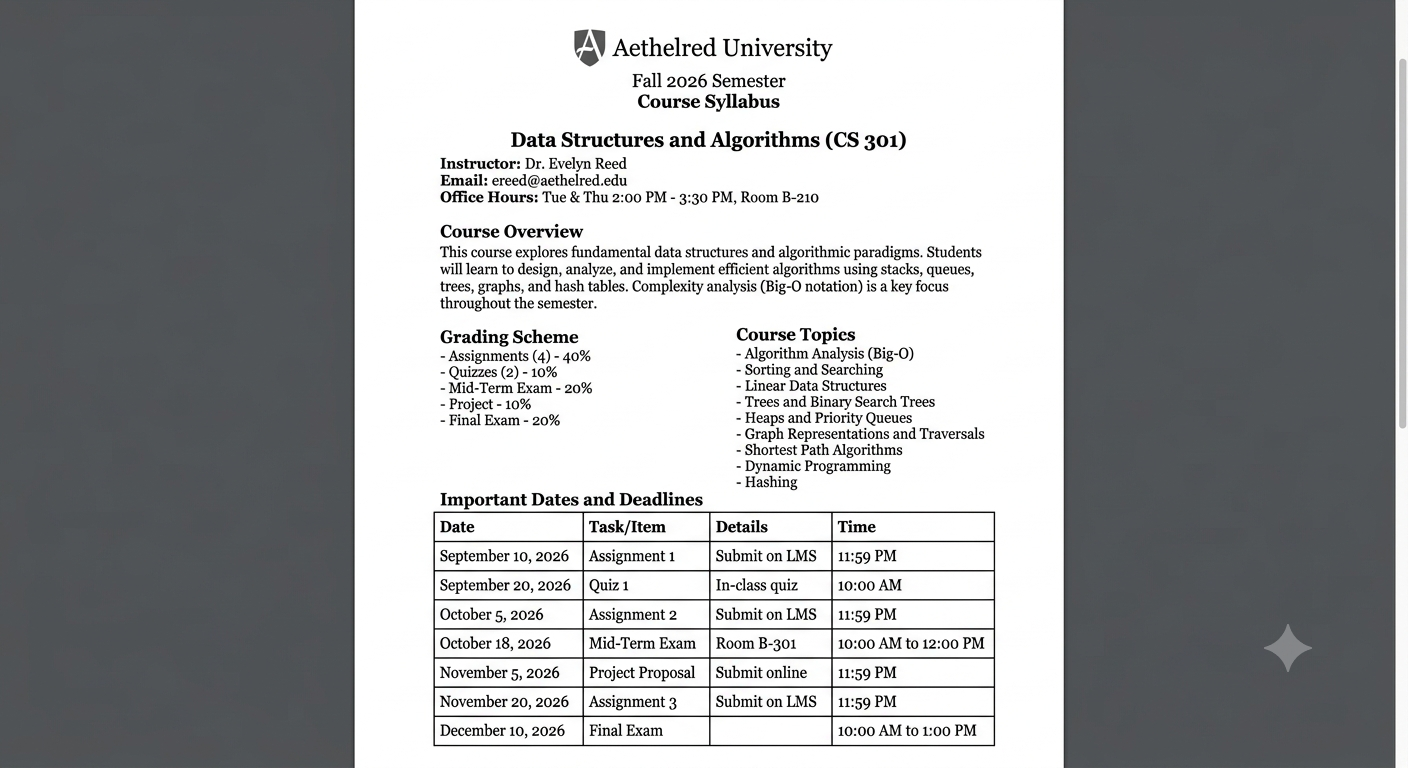

In [50]:
image_path = "test1.png"

image = Image.open(image_path)

display(image)

In [51]:
response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[
        deadline_prompt,
        image
    ]
)

print(response.text)

{
  "deadlines": [
    {
      "date_time": "September 10, 2026, 11:59 PM",
      "task_event": "Assignment 1",
      "subject_course": "CS 301",
      "type": "Assignment",
      "additional_notes": "Submit on LMS"
    },
    {
      "date_time": "September 20, 2026, 10:00 AM",
      "task_event": "Quiz 1",
      "subject_course": "CS 301",
      "type": "Quiz",
      "additional_notes": "In-class quiz"
    },
    {
      "date_time": "October 5, 2026, 11:59 PM",
      "task_event": "Assignment 2",
      "subject_course": "CS 301",
      "type": "Assignment",
      "additional_notes": "Submit on LMS"
    },
    {
      "date_time": "October 18, 2026, 10:00 AM to 12:00 PM",
      "task_event": "Mid-Term Exam",
      "subject_course": "CS 301",
      "type": "Exam",
      "additional_notes": "Room B-301"
    },
    {
      "date_time": "November 5, 2026, 11:59 PM",
      "task_event": "Project Proposal",
      "subject_course": "CS 301",
      "type": "Project",
      "additional_notes"

In [14]:
from IPython.display import Markdown, display

display(Markdown(response.text))

| Date & Time | Task / Event | Subject / Course | Type | Additional Notes |
| :--- | :--- | :--- | :--- | :--- |
| August 29, 11:59 pm | MP-00 | Physics 140 | Assignment | Mastering Physics assignment |
| September 02, 08:55 am | A-01 | Physics 140 | Assignment | Not specified |
| September 05, 11:59 pm | MP-01 | Physics 140 | Assignment | Mastering Physics assignment |
| September 08, 08:55 am | A-02 | Physics 140 | Assignment | Not specified |
| September 10, 08:55 am | A-03 | Physics 140 | Assignment | Not specified |
| September 12, 11:59 pm | MP-02 | Physics 140 | Assignment | Mastering Physics assignment |
| September 15, 08:55 am | A-04 | Physics 140 | Assignment | Not specified |
| September 15, 06:00 pm | Exam 1 | Physics 140 | Exam | Covers Chapters 1–3 |
| September 17, 08:55 am | A-05 | Physics 140 | Assignment | Not specified |
| September 19, 11:59 pm | MP-03 | Physics 140 | Assignment | Mastering Physics assignment |
| September 22, 08:55 am | A-06 | Physics 140 | Assignment | Not specified |
| September 26, 11:59 pm | MP-04 | Physics 140 | Assignment | Mastering Physics assignment |
| September 29, 08:55 am | A-07 | Physics 140 | Assignment | Not specified |
| October 01, 08:55 am | A-08 | Physics 140 | Assignment | Not specified |
| October 02, 08:55 am | A-09 | Physics 140 | Assignment | Not specified |
| October 03, 11:59 pm | MP-05 | Physics 140 | Assignment | Mastering Physics assignment |
| October 06, 06:00 pm | Exam 2 | Physics 140 | Exam | Covers Sections 4.1–7.3 |
| October 08, 08:55 am | A-10 | Physics 140 | Assignment | Not specified |
| October 09, 08:55 am | A-11-12 | Physics 140 | Assignment | Not specified |
| October 10, 11:59 pm | MP-06 | Physics 140 | Assignment | Mastering Physics assignment |
| October 16, 11:59 pm | MP-07 | Physics 140 | Assignment | Mastering Physics assignment |

In [15]:
deadline_result = response.text

print("Deadline extraction completed.")

Deadline extraction completed.


In [25]:
test_images = [
    ("test1.png", "Test 1 - Syllabus with deadlines"),
    ("test2.png", "Test 2 - Timetable"),
    ("test3.png", "Test 3 - No deadlines"),
]

Test 1 - Syllabus with deadlines


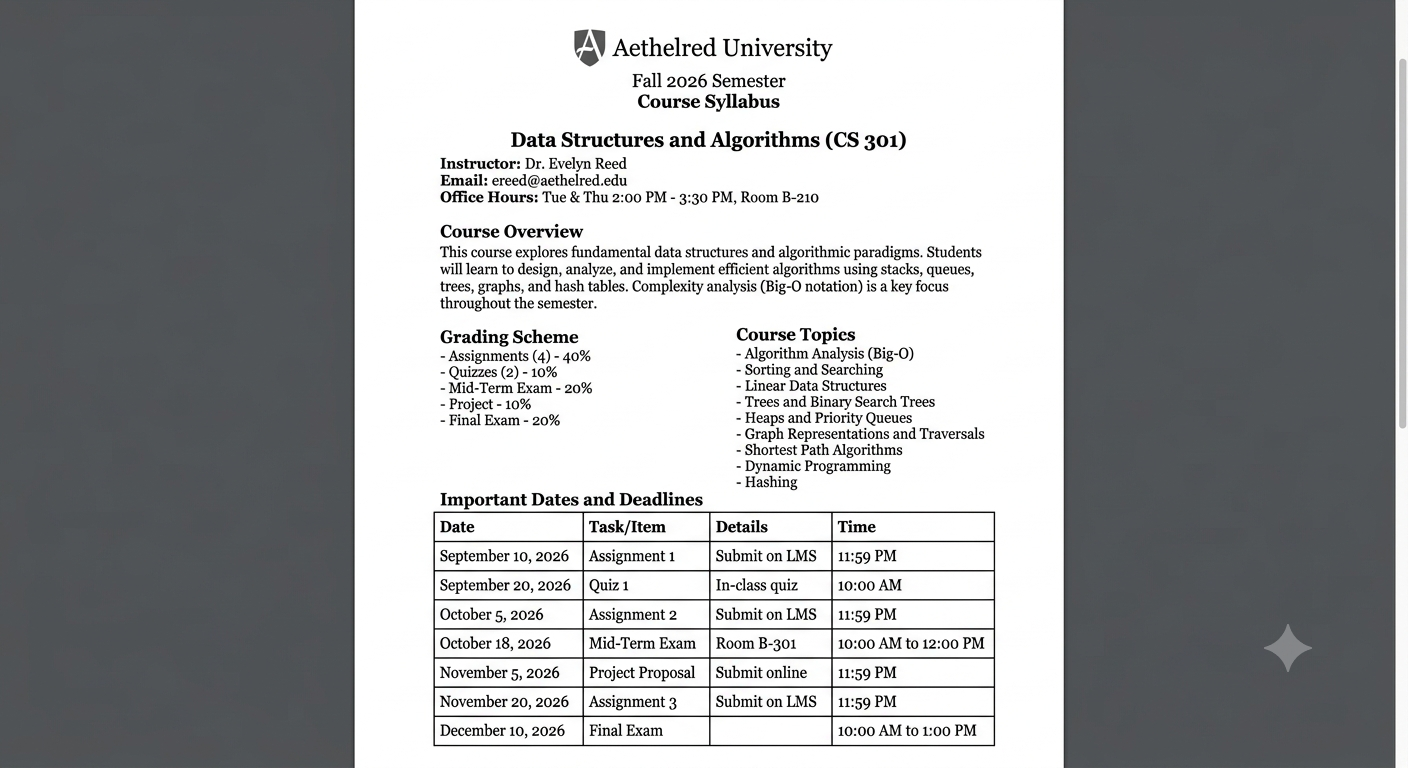

| Date & Time | Task / Event | Subject / Course | Type | Additional Notes |
| :--- | :--- | :--- | :--- | :--- |
| September 10, 2026, 11:59 PM | Assignment 1 | Data Structures and Algorithms (CS 301) | Assignment | Submit on LMS |
| September 20, 2026, 10:00 AM | Quiz 1 | Data Structures and Algorithms (CS 301) | Quiz | In-class quiz |
| October 5, 2026, 11:59 PM | Assignment 2 | Data Structures and Algorithms (CS 301) | Assignment | Submit on LMS |
| October 18, 2026, 10:00 AM to 12:00 PM | Mid-Term Exam | Data Structures and Algorithms (CS 301) | Exam | Room B-301 |
| November 5, 2026, 11:59 PM | Project Proposal | Data Structures and Algorithms (CS 301) | Project | Submit online |
| November 20, 2026, 11:59 PM | Assignment 3 | Data Structures and Algorithms (CS 301) | Assignment | Submit on LMS |
| December 10, 2026, 10:00 AM to 1:00 PM | Final Exam | Data Structures and Algorithms (CS 301) | Exam | Not specified |

Test 2 - Timetable


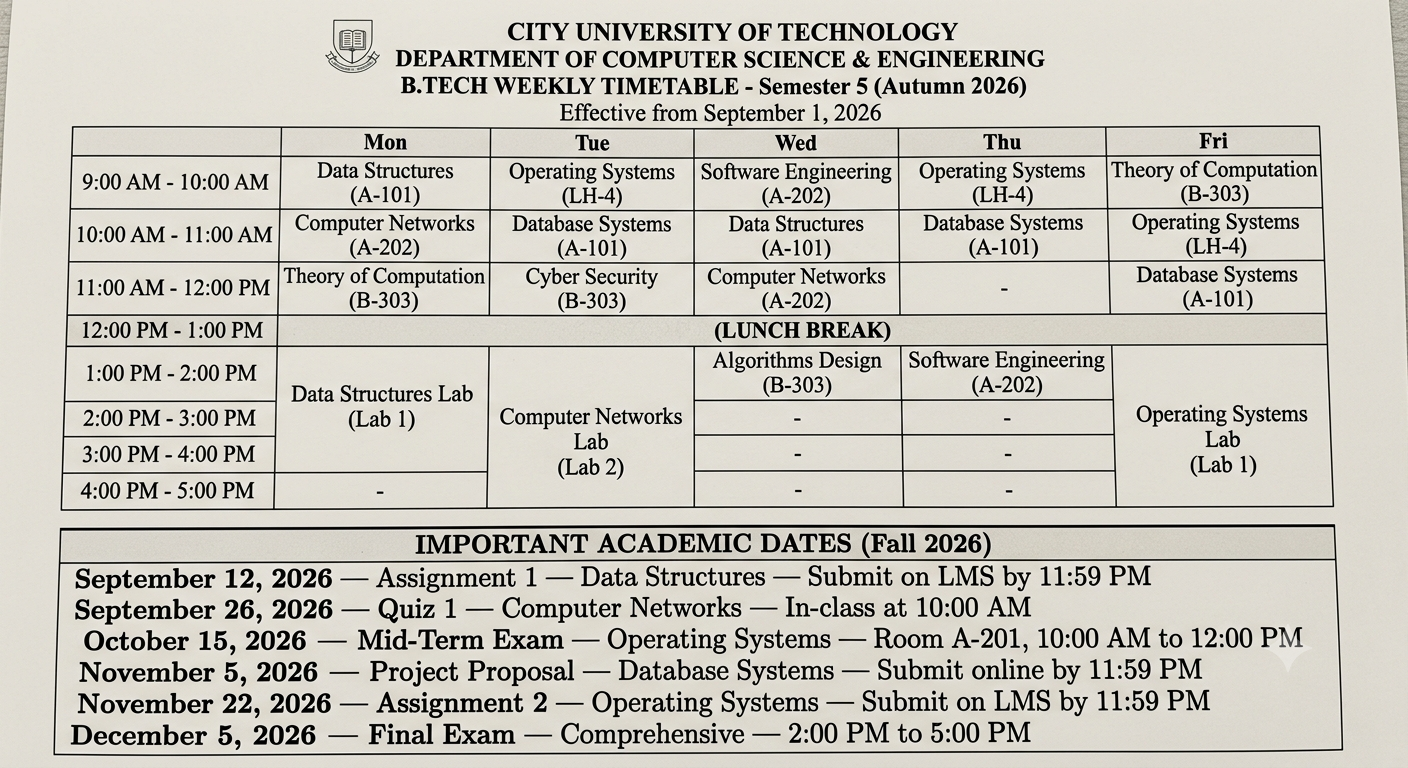

No academic deadlines were found in the provided image.

*(Note: The document contains a class schedule/timetable and a list of important academic dates with deadlines, which I have extracted below for your convenience in a structured format.)*

| Date & Time | Task / Event | Subject / Course | Type | Additional Notes |
| :--- | :--- | :--- | :--- | :--- |
| September 12, 2026, 11:59 PM | Assignment 1 | Data Structures | Assignment | Submit on LMS by 11:59 PM |
| September 26, 2026, 10:00 AM | Quiz 1 | Computer Networks | Quiz | In-class at 10:00 AM |
| October 15, 2026, 10:00 AM - 12:00 PM | Mid-Term Exam | Operating Systems | Exam | Room A- |
| November 5, 2026, 11:59 PM | Project Proposal | Database Systems | Project | Submit online by 11:59 PM |
| November 22, 2026, 11:59 PM | Assignment 2 | Operating Systems | Assignment | Submit on LMS by 11:59 PM |
| December 5, 2026, 2:00 PM - 5:00 PM | Final Exam | Comprehensive | Exam | 2:00 PM to 5:00 PM |

Test 3 - No deadlines


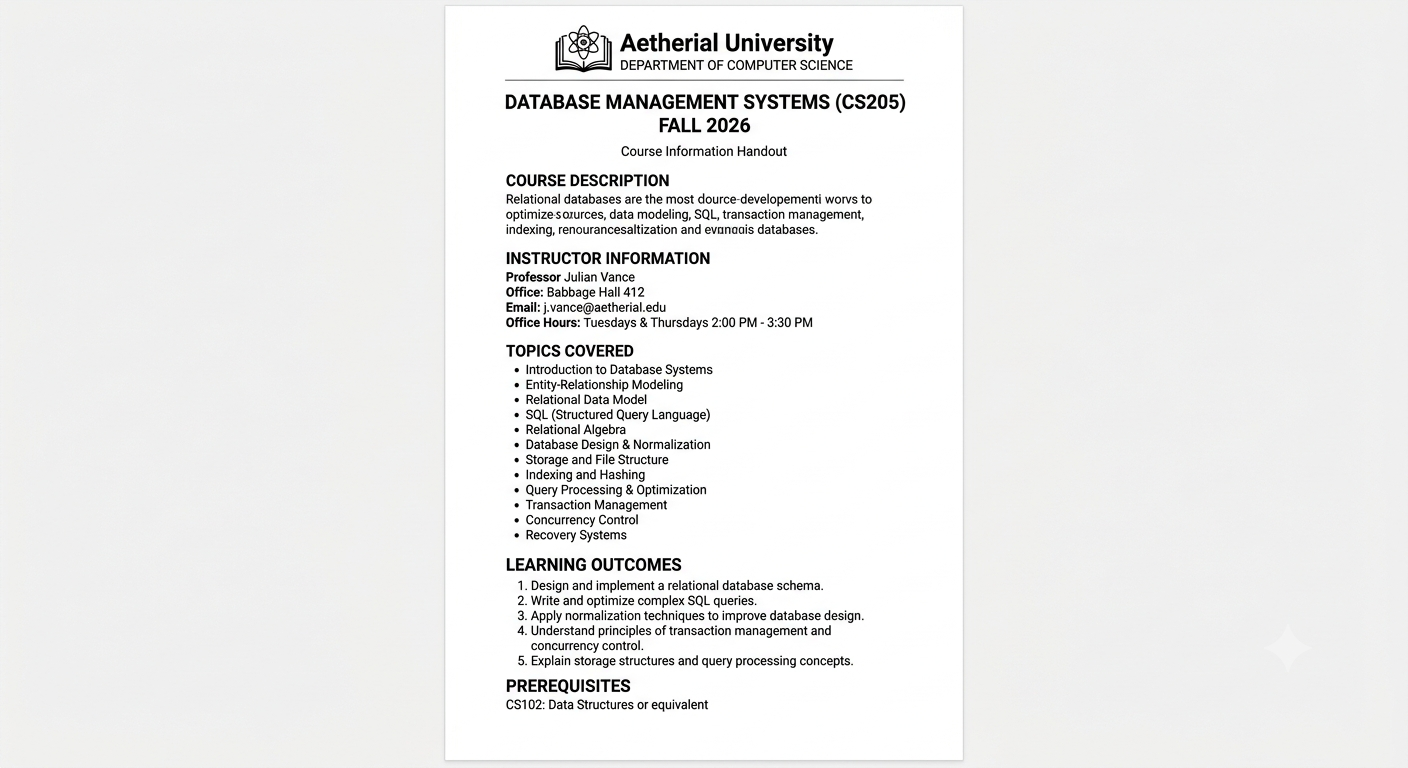

No academic deadlines were found in the provided image.

In [26]:
for image_path, description in test_images:

    print("=" * 70)
    print(description)
    print("=" * 70)

    image = Image.open(image_path)

    display(image)

    response = client.models.generate_content(
        model="gemini-3.5-flash-lite",
        contents=[
            deadline_prompt,
            image
        ]
    )

    display(Markdown(response.text))

In [31]:

GMAIL_ADDRESS = "imsuyashdoss@gmail.com"
GMAIL_APP_PASSWORD = "nxcs zrxk nkoa ylyc"

In [32]:
import smtplib
from email.mime.text import MIMEText

In [33]:
test_email = MIMEText(
    "Hello!\n\n"
    "This is a test email from my AI Deadline Tracker."
)

test_email["Subject"] = "AI Deadline Tracker - Test"
test_email["From"] = GMAIL_ADDRESS
test_email["To"] = GMAIL_ADDRESS

In [34]:
with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
    server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
    server.send_message(test_email)

print("Test email sent successfully!")

Test email sent successfully!


In [37]:
def send_deadline_email(to_address, deadline_result):

    email = MIMEText(
        "Hello,\n\n"
        "Here is your Academic Deadline Digest:\n\n"
        + deadline_result
        + "\n\n"
        "Please review the deadlines and plan accordingly.\n\n"
        "AI Academic Deadline Tracker"
    )

    email["Subject"] = "Your Academic Deadline Digest"
    email["From"] = GMAIL_ADDRESS
    email["To"] = to_address

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
        server.send_message(email)

    print("Deadline digest sent successfully!")

In [38]:
print(deadline_result)

| Date & Time | Task / Event | Subject / Course | Type | Additional Notes |
| :--- | :--- | :--- | :--- | :--- |
| August 29, 11:59 pm | MP-00 | Physics 140 | Assignment | Mastering Physics assignment |
| September 02, 08:55 am | A-01 | Physics 140 | Assignment | Not specified |
| September 05, 11:59 pm | MP-01 | Physics 140 | Assignment | Mastering Physics assignment |
| September 08, 08:55 am | A-02 | Physics 140 | Assignment | Not specified |
| September 10, 08:55 am | A-03 | Physics 140 | Assignment | Not specified |
| September 12, 11:59 pm | MP-02 | Physics 140 | Assignment | Mastering Physics assignment |
| September 15, 08:55 am | A-04 | Physics 140 | Assignment | Not specified |
| September 15, 06:00 pm | Exam 1 | Physics 140 | Exam | Covers Chapters 1–3 |
| September 17, 08:55 am | A-05 | Physics 140 | Assignment | Not specified |
| September 19, 11:59 pm | MP-03 | Physics 140 | Assignment | Mastering Physics assignment |
| September 22, 08:55 am | A-06 | Physics 140 | Assign

In [39]:
from email.mime.text import MIMEText

email = MIMEText(
    "Deadline 1: DBMS Assignment - October 10, 2026\n"
    "Deadline 2: OS Mid-Term - October 15, 2026\n"
    "Deadline 3: AI Project - November 5, 2026"
)

email["Subject"] = "Deadline Tracker Test 2"
email["From"] = GMAIL_ADDRESS
email["To"] = GMAIL_ADDRESS

with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
    server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
    result = server.send_message(email)

print("SMTP result:", result)
print("Email sent!")

SMTP result: {}
Email sent!


In [40]:
print(type(deadline_result))
print("----------")
print(deadline_result)

<class 'str'>
----------
| Date & Time | Task / Event | Subject / Course | Type | Additional Notes |
| :--- | :--- | :--- | :--- | :--- |
| August 29, 11:59 pm | MP-00 | Physics 140 | Assignment | Mastering Physics assignment |
| September 02, 08:55 am | A-01 | Physics 140 | Assignment | Not specified |
| September 05, 11:59 pm | MP-01 | Physics 140 | Assignment | Mastering Physics assignment |
| September 08, 08:55 am | A-02 | Physics 140 | Assignment | Not specified |
| September 10, 08:55 am | A-03 | Physics 140 | Assignment | Not specified |
| September 12, 11:59 pm | MP-02 | Physics 140 | Assignment | Mastering Physics assignment |
| September 15, 08:55 am | A-04 | Physics 140 | Assignment | Not specified |
| September 15, 06:00 pm | Exam 1 | Physics 140 | Exam | Covers Chapters 1–3 |
| September 17, 08:55 am | A-05 | Physics 140 | Assignment | Not specified |
| September 19, 11:59 pm | MP-03 | Physics 140 | Assignment | Mastering Physics assignment |
| September 22, 08:55 am | A-

In [41]:
email_body = f"""
Hello,

Here is your Academic Deadline Digest:

{deadline_result}

Please review the deadlines and plan accordingly.

Regards,
AI Academic Deadline Tracker
"""

print(email_body)


Hello,

Here is your Academic Deadline Digest:

| Date & Time | Task / Event | Subject / Course | Type | Additional Notes |
| :--- | :--- | :--- | :--- | :--- |
| August 29, 11:59 pm | MP-00 | Physics 140 | Assignment | Mastering Physics assignment |
| September 02, 08:55 am | A-01 | Physics 140 | Assignment | Not specified |
| September 05, 11:59 pm | MP-01 | Physics 140 | Assignment | Mastering Physics assignment |
| September 08, 08:55 am | A-02 | Physics 140 | Assignment | Not specified |
| September 10, 08:55 am | A-03 | Physics 140 | Assignment | Not specified |
| September 12, 11:59 pm | MP-02 | Physics 140 | Assignment | Mastering Physics assignment |
| September 15, 08:55 am | A-04 | Physics 140 | Assignment | Not specified |
| September 15, 06:00 pm | Exam 1 | Physics 140 | Exam | Covers Chapters 1–3 |
| September 17, 08:55 am | A-05 | Physics 140 | Assignment | Not specified |
| September 19, 11:59 pm | MP-03 | Physics 140 | Assignment | Mastering Physics assignment |
| Sep

In [42]:
email = MIMEText(email_body)

email["Subject"] = "Your Academic Deadline Digest"
email["From"] = GMAIL_ADDRESS
email["To"] = GMAIL_ADDRESS

with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
    server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
    result = server.send_message(email)

print("SMTP result:", result)
print("Deadline digest sent successfully!")

SMTP result: {}
Deadline digest sent successfully!


In [43]:
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

In [44]:
email = MIMEMultipart("alternative")

email["Subject"] = "Your Academic Deadline Digest"
email["From"] = GMAIL_ADDRESS
email["To"] = GMAIL_ADDRESS

In [45]:
html_body = f"""
<html>
<body style="font-family: Arial, sans-serif; background-color: #f4f6f8; padding: 20px;">

<div style="
    max-width: 700px;
    margin: auto;
    background-color: white;
    padding: 30px;
    border-radius: 10px;
">

    <h1 style="color: #1f4e79;">
        Academic Deadline Tracker
    </h1>

    <p style="color: #555;">
        Here is your latest academic deadline digest.
    </p>

    <hr>

    <div style="
        margin-top: 20px;
        padding: 15px;
        background-color: #f8fafc;
        border-left: 4px solid #1f4e79;
    ">
        <strong>Important:</strong>
        Please review the deadlines below and plan your academic work accordingly.
    </div>

    <h2 style="color: #1f4e79; margin-top: 25px;">
        Extracted Deadlines
    </h2>

    <div style="font-size: 14px; line-height: 1.6;">
        {deadline_result}
    </div>

    <hr style="margin-top: 30px;">

    <p style="
        text-align: center;
        color: #888;
        font-size: 12px;
    ">
        Generated by AI Academic Deadline Tracker
    </p>

</div>

</body>
</html>
"""

In [46]:
email.attach(MIMEText(html_body, "html"))

In [47]:
with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
    server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
    server.send_message(email)

print("Professional deadline digest sent successfully!")

Professional deadline digest sent successfully!


In [48]:
deadline_prompt = """
You are an AI Academic Deadline Tracker.

Analyze the uploaded image carefully. The image may contain a syllabus,
timetable, assignment sheet, project schedule, or other academic documents.

Your task is to extract all important academic deadlines, exam dates,
and milestones clearly visible in the image.

Return ONLY valid JSON in the following format:

{
  "deadlines": [
    {
      "date_time": "Oct 15, 11:59 PM",
      "task_event": "Assignment 1",
      "subject_course": "Mathematics",
      "type": "Assignment",
      "additional_notes": "Submit through LMS"
    }
  ]
}

Rules:
1. Extract only information clearly visible in the image.
2. If information for a field is missing, use "Not specified".
3. Do not invent, guess, or calculate dates.
4. Only include dates explicitly associated with an academic event,
   deadline, exam, quiz, assignment, project, reading, or milestone.
5. Do not treat document creation dates, publication dates, semester
   labels, or page headers as deadlines.
6. Sort the deadlines chronologically from earliest to latest.
7. Type must be one of:
   Assignment, Exam, Project, Quiz, Reading, or Other.
8. If no academic deadlines are found, return:

{
  "deadlines": []
}

Return ONLY the JSON. Do not include Markdown fences or explanations.
"""

In [52]:
import json

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[
        deadline_prompt,
        image
    ]
)

deadline_data = json.loads(response.text)

print(deadline_data)

{'deadlines': [{'date_time': 'September 10, 2026, 11:59 PM', 'task_event': 'Assignment 1', 'subject_course': 'CS 301', 'type': 'Assignment', 'additional_notes': 'Submit on LMS'}, {'date_time': 'September 20, 2026, 10:00 AM', 'task_event': 'Quiz 1', 'subject_course': 'CS 301', 'type': 'Quiz', 'additional_notes': 'In-class quiz'}, {'date_time': 'October 5, 2026, 11:59 PM', 'task_event': 'Assignment 2', 'subject_course': 'CS 301', 'type': 'Assignment', 'additional_notes': 'Submit on LMS'}, {'date_time': 'October 18, 2026, 10:00 AM to 12:00 PM', 'task_event': 'Mid-Term Exam', 'subject_course': 'CS 301', 'type': 'Exam', 'additional_notes': 'Room B-301'}, {'date_time': 'November 5, 2026, 11:59 PM', 'task_event': 'Project Proposal', 'subject_course': 'CS 301', 'type': 'Project', 'additional_notes': 'Submit online'}, {'date_time': 'November 20, 2026, 11:59 PM', 'task_event': 'Assignment 3', 'subject_course': 'CS 301', 'type': 'Assignment', 'additional_notes': 'Submit on LMS'}, {'date_time': 'D

In [53]:
rows = ""

for deadline in deadline_data["deadlines"]:
    rows += f"""
    <tr>
        <td>{deadline["date_time"]}</td>
        <td>{deadline["task_event"]}</td>
        <td>{deadline["subject_course"]}</td>
        <td>{deadline["type"]}</td>
        <td>{deadline["additional_notes"]}</td>
    </tr>
    """

In [54]:
if deadline_data["deadlines"]:

    deadline_table = f"""
    <table style="
        width: 100%;
        border-collapse: collapse;
        margin-top: 15px;
        font-size: 14px;
    ">

        <thead>
            <tr style="background-color: #1f4e79; color: white;">
                <th style="padding: 12px; border: 1px solid #ddd;">
                    Date & Time
                </th>

                <th style="padding: 12px; border: 1px solid #ddd;">
                    Task / Event
                </th>

                <th style="padding: 12px; border: 1px solid #ddd;">
                    Subject / Course
                </th>

                <th style="padding: 12px; border: 1px solid #ddd;">
                    Type
                </th>

                <th style="padding: 12px; border: 1px solid #ddd;">
                    Additional Notes
                </th>
            </tr>
        </thead>

        <tbody>
            {rows}
        </tbody>

    </table>
    """

else:

    deadline_table = """
    <div style="
        padding: 20px;
        background-color: #f8f9fa;
        border-radius: 8px;
        text-align: center;
    ">
        <strong>No academic deadlines were found.</strong>
    </div>
    """

In [55]:
from IPython.display import display, HTML

display(HTML(deadline_table))

Date & Time,Task / Event,Subject / Course,Type,Additional Notes
"September 10, 2026, 11:59 PM",Assignment 1,CS 301,Assignment,Submit on LMS
"September 20, 2026, 10:00 AM",Quiz 1,CS 301,Quiz,In-class quiz
"October 5, 2026, 11:59 PM",Assignment 2,CS 301,Assignment,Submit on LMS
"October 18, 2026, 10:00 AM to 12:00 PM",Mid-Term Exam,CS 301,Exam,Room B-301
"November 5, 2026, 11:59 PM",Project Proposal,CS 301,Project,Submit online
"November 20, 2026, 11:59 PM",Assignment 3,CS 301,Assignment,Submit on LMS
"December 10, 2026, 10:00 AM to 1:00 PM",Final Exam,CS 301,Exam,Not specified


In [56]:
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

email = MIMEMultipart("alternative")

email["Subject"] = "Your Academic Deadline Digest"
email["From"] = GMAIL_ADDRESS
email["To"] = GMAIL_ADDRESS

In [57]:
html_body = f"""
<html>
<body style="
    margin: 0;
    padding: 20px;
    background-color: #f4f6f8;
    font-family: Arial, sans-serif;
">

<div style="
    max-width: 900px;
    margin: auto;
    background-color: white;
    padding: 30px;
    border-radius: 10px;
">

    <h1 style="color: #1f4e79;">
        Academic Deadline Tracker
    </h1>

    <p style="color: #555;">
        Here is your latest academic deadline digest.
    </p>

    <div style="
        margin: 20px 0;
        padding: 15px;
        background-color: #eef5fb;
        border-left: 4px solid #1f4e79;
    ">
        <strong>Important:</strong>
        Review the deadlines below and plan your academic work accordingly.
    </div>

    <h2 style="color: #1f4e79;">
        Academic Deadlines
    </h2>

    {deadline_table}

    <p style="
        margin-top: 30px;
        color: #777;
        font-size: 13px;
    ">
        This digest was generated by the AI Academic Deadline Tracker.
    </p>

</div>

</body>
</html>
"""

In [58]:
email.attach(MIMEText(html_body, "html"))

with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
    server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
    server.send_message(email)

print("Professional deadline digest sent successfully!")

Professional deadline digest sent successfully!


In [59]:
import re

recipient_email = input("Enter student's email address: ").strip()

email_pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

if re.fullmatch(email_pattern, recipient_email):
    print("Valid email:", recipient_email)
else:
    print("Invalid email address.")
    recipient_email = None

Valid email: suyashsrivastava614@gmail.com


In [60]:
if recipient_email is not None:

    email = MIMEMultipart("alternative")

    email["Subject"] = "Your Academic Deadline Digest"
    email["From"] = GMAIL_ADDRESS
    email["To"] = recipient_email

    email.attach(MIMEText(html_body, "html"))

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
        result = server.send_message(email)

    print("SMTP result:", result)
    print("Email accepted for delivery to:", recipient_email)

else:
    print("Please enter a valid email address.")

SMTP result: {}
Email accepted for delivery to: suyashsrivastava614@gmail.com


In [61]:
!pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.6
    Uninstalling protobuf-6.33.6:
      Successfully uninstalled protobuf-6.33.6
  Attempting uninstall: rich
    Found existing installation: rich 15.0.0
    Uninstalling rich-15.0.0:
      Successfully uninstalled rich-15.0.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.6 which is incompatible.
